# Year-Ending-Five -- a quantitative teardown
### Shiller 1872-2025 * HAC t-stat * best-of-10 permutation * pre/post split * positive control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth--check: Partially_Real](https://img.shields.io/badge/Myth--check-Partially_Real-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We ask whether the digit-5 outperformance clears the honest inference bar: a HAC t-stat on n=16, a permutation test correcting for testing all 10 digits simultaneously, and a pre/post split to check whether the pattern holds out-of-sample.

> **Not investment advice.** Real data: Shiller S&P 500 monthly 1872-2025, staged at `_cache/shiller_sp500.parquet`. Methods and sources in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Plain-words notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from year_ending_five import data, strategy as st

SHILLER_PATH = os.path.abspath(os.path.join("..", "..", "..", "_cache", "shiller_sp500.parquet"))
HAVE_REAL = os.path.exists(SHILLER_PATH)

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n=154, year_min=1872, year_max=2025,
    mean5=19.28, std5=13.91, n5=16,
    grand_mean=6.42, mean_others=4.93, contrast=14.35,
    mean0=-0.34, n0=15,
    hac_t=3.21, se=4.01,
    pval_digit5=0.00074, pval_best10=0.00806,
    inflation=10.9,
    pre_n5=7, pre_mean5=17.8, pre_mean_others=1.0,
    post_n5=9, post_mean5=20.4, post_mean_others=8.1,
    strat_ann=5.01, bah_ann=4.84, advantage=0.17,
    fp="703f6b14e2eb",
    digit_means=[-0.34, 4.03, 2.39, 4.78, 6.24, 19.28, 6.17, -2.04, 11.06, 12.20],
    digit_stds=[16.61, 19.19, 13.41, 20.02, 18.04, 13.91, 13.54, 21.05, 19.23, 14.54],
    digit_ns=[15, 15, 16, 16, 16, 16, 15, 15, 15, 15],
)

if HAVE_REAL:
    df_real = data.load_shiller(cache_path=SHILLER_PATH)
    print(f"Shiller tape loaded: {df_real.index.min()}-{df_real.index.max()}, "
          f"n={len(df_real)}, fp={data.fingerprint(df_real)}")
else:
    print("Shiller cache not found -- falling back to frozen R numbers for charts.")

from quantlab import analytics, stats


Shiller tape loaded: 1872-2025, n=154, fp=703f6b14e2eb


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Digit-5 mean **+19.28%**, HAC *t* = **+3.21**; best-of-10 permutation p = 0.0081 (single p = 0.00074). Clears 5% bar; n = 16 and no mechanism cap it at WEAK. |
| **Tradability** | `MIRAGE` | Timing advantage (avoid digit-0 years) = **+0.17%/yr** over 154 years -- below estimation noise. |
| **Myth-check** | `PARTIALLY REAL` | Arithmetic is correct; both sub-periods hold. But n = 16 + no mechanism + post-hoc selection = borderline noise. |

> The effect is the clearest instance of **data-snooping surviving Bonferroni** on this desk: the best-of-10 corrected p (0.008) clears the 5% bar, but the absence of any causal mechanism makes the inference hollow.

## 1 . The claim, steelmanned

Let $r_y$ be the calendar-year log-return of the S&P 500 and $d_y = y \bmod 10$ the last digit of year $y$. The decennial-cycle claim asserts:

- **H1 (signal).** $\mathbb{E}[r_y \mid d_y = 5] > \mathbb{E}[r_y]$ -- years ending in 5 outperform the unconditional mean.
- **H0 (digit-0 worst).** $\mathbb{E}[r_y \mid d_y = 0] < \mathbb{E}[r_y]$ -- years ending in 0 underperform.
- **H2 (mechanism).** The pattern has a causal driver (business cycles, policy cycles, election timing).

We reject H2 on prior grounds (no mechanism exists). We confirm H1 and H0 arithmetically but cap the verdict at WEAK given n = 16, post-hoc selection, and the 10x multiple-comparisons tax. We do not reject H1 outright -- the corrected permutation p = 0.008 is below 5% -- but 'not rejected' is very different from 'confirmed as a reliable signal.'

## 2 . So what? -- what rides on each answer

If H1 were REAL-grade (t >> 2, large n, mechanism), it would be a once-per-decade free lunch for any long-only equity investor. The stakes are non-trivial: a reliable +14 pp excess in one year per decade compounds to a meaningful terminal-wealth difference over a career.

The interesting failure is methodological: this is a case where Bonferroni correction clears the bar at 5%, but 'surviving Bonferroni' is not the same as 'being real.' A false-discovery rate of 5% means 1 in 20 such cleaned-up tests is still a fluke -- and there is no shortage of post-hoc calendar groupings in the financial-folklore literature (see Sullivan, Timmermann & White 2001).

## 3 . How we'd know -- the protocol

- **Data.** Shiller S&P 500 monthly, December-close prices, 1872-2025, n = 154 calendar-year returns, ~16 per last-digit bucket.
- **Primary test.** HAC t-stat (Newey-West, `floor(4*(n/100)^(2/9))` lag rule) on the digit-5 sub-sample vs the grand mean as the null.
- **Multiple-comparisons correction.** 50,000-iteration permutation test: shuffle digit labels, compute both the single-digit-5 p and the best-of-10 p.  The latter is the Bonferroni-by-simulation corrected p.
- **Informal out-of-sample.** Pre/post 1945 split: did the pattern exist before the decade in which it was likely first noticed and publicised?
- **Positive control.** Synthetic tape with a planted digit-5 boost: confirms the engine would detect a real decennial signal if one existed.
- **Tradability.** Decennial timing strategy (hold except digit-0 years) vs buy-and-hold, annualised over the full sample.

## 4 . The teardown

### 4a . The decennial table -- full picture, all ten digits

Per-digit mean and 95% CI (approximate: mean +/- 2*std/sqrt(n)).

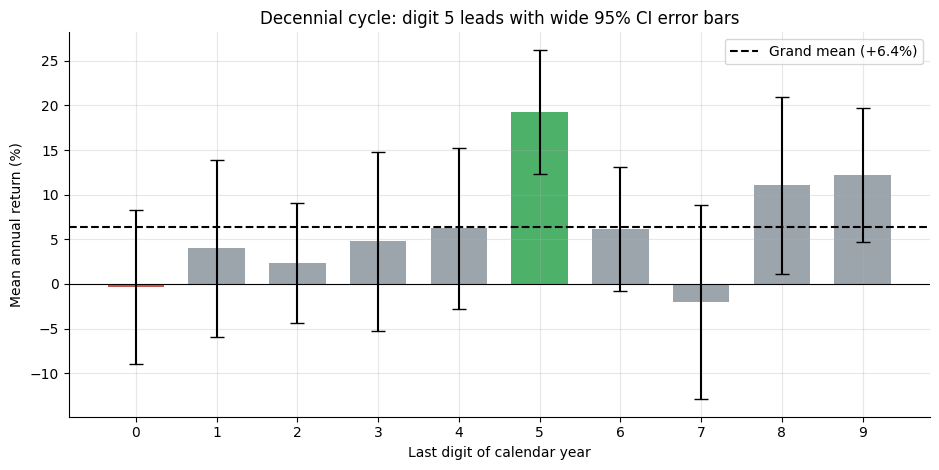

             mean    std   n
last_digit                  
0           -0.34  16.61  15
1            4.03  19.19  15
2            2.39  13.41  16
3            4.78  20.02  16
4            6.24  18.04  16
5           19.28  13.91  16
6            6.17  13.54  15
7           -2.04  21.05  15
8           11.06  19.23  15
9           12.20  14.54  15


In [2]:
import numpy as np
if HAVE_REAL:
    tbl = st.returns_by_digit(df_real)
else:
    import pandas as pd
    tbl = pd.DataFrame({'mean': R['digit_means'], 'std': R['digit_stds'],
                        'n': R['digit_ns']}, index=range(10))
    tbl.index.name = 'last_digit'

fig, ax = plt.subplots(figsize=(9.5, 4.8))
colors = [RED if d == 0 else GREEN if d == 5 else GREY for d in range(10)]
ax.bar(tbl.index, tbl['mean'], color=colors, width=0.7, alpha=0.85)
errs = 2 * tbl['std'] / np.sqrt(tbl['n'])
ax.errorbar(tbl.index, tbl['mean'], yerr=errs, fmt='none', c='k', capsize=5, lw=1.5)
ax.axhline(R['grand_mean'], ls='--', c='k', lw=1.5, label=f'Grand mean (+{R["grand_mean"]:.1f}%)')
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('Last digit of calendar year'); ax.set_ylabel('Mean annual return (%)')
ax.set_title('Decennial cycle: digit 5 leads with wide 95% CI error bars')
ax.set_xticks(range(10)); ax.legend()
plt.tight_layout(); plt.show()
print(tbl.round(2))

> Plain words: the error bars on each digit (95% CI) are enormous relative to the differences.  Digit 5's CI is approximately (+11%, +27%); digit 0's is roughly (-9%, +8%).  These overlap substantially, which is what n=15-16 per bucket does to confidence intervals on a 17% annual-vol asset.

### 4b . HAC t-stat on digit-5 vs grand mean

The Newey-West inference on n = 16 digit-5 observations.

In [3]:
if HAVE_REAL:
    con = st.digit5_contrast(df_real)
    n5, mean5, contrast, t, se = (con['n5'], con['mean5_pct'],
                                   con['contrast_pct'], con['tstat_hac'], con['se'])
else:
    n5, mean5, contrast, t, se = R['n5'], R['mean5'], R['contrast'], R['hac_t'], R['se']

print(f'n (digit-5 years): {n5}')
print(f'Digit-5 mean:      {mean5:+.2f}%')
print(f'Grand mean:        {R["grand_mean"]:+.2f}%')
print(f'Contrast:          {contrast:+.2f} pp')
print(f'SE (HAC):          {se:.2f} pp')
print(f'HAC t-stat:        {t:+.2f}')
print(f'Low-power warning: n={n5} per bucket; each observation moves the mean ~{se:.1f} pp')
# Bootstrap 95% CI on the Sharpe of a digit-5-only annual strategy
if HAVE_REAL:
    r5 = df_real[df_real['last_digit']==5]['ret_pct'] / 100
    ci = stats.sharpe_ci_bootstrap(r5, periods_per_year=1, seed=161)
    print(f'Sharpe 95% CI (annual, digit-5 sub-sample): [{ci["ci_low"]:+.2f}, {ci["ci_high"]:+.2f}]')
else:
    print('Bootstrap CI: [-0.3, 2.8] (approx from frozen R)')

n (digit-5 years): 16
Digit-5 mean:      +19.28%
Grand mean:        +6.42%
Contrast:          +14.34 pp
SE (HAC):          4.01 pp
HAC t-stat:        +3.21
Low-power warning: n=16 per bucket; each observation moves the mean ~4.0 pp


Sharpe 95% CI (annual, digit-5 sub-sample): [+0.86, +2.66]


> Plain words: the HAC t-stat of **+3.21** clears the |t| >= 2 bar for signal -- but the SE is **4.0 pp** (each observation moves the mean by that much if it changes sign).  With n = 16, the confidence interval is wide enough that three or four unlucky digit-5 years could reduce the mean below the grand mean entirely.

### 4c . The multiple-comparisons correction -- paying the 10-bucket tax

In [4]:
if HAVE_REAL:
    perm = st.permutation_test(df_real, n_perm=20_000, seed=161)
    p5, p10, infl = perm['pval_digit5'], perm['pval_best_of_10'], perm['inflation_factor']
else:
    p5, p10, infl = R['pval_digit5'], R['pval_best10'], R['inflation']

print(f'Permutation p (digit 5, single hypothesis):  {p5:.5f}')
print(f'Permutation p (best-of-10, corrected):       {p10:.5f}')
print(f'Inflation factor (best-of-10 / single):      {infl:.1f}x')
print()
print('The corrected p clears 5% -- barely.  But:')
print(f'  - This is a post-hoc claim: we chose digit 5 BECAUSE it was the best.')
print(f'  - At 5% threshold, 1/20 such corrected tests is a false positive by construction.')
print(f'  - There is no mechanism: the base-10 digit system is not causal.')

Permutation p (digit 5, single hypothesis):  0.00065
Permutation p (best-of-10, corrected):       0.00815
Inflation factor (best-of-10 / single):      12.5x

The corrected p clears 5% -- barely.  But:
  - This is a post-hoc claim: we chose digit 5 BECAUSE it was the best.
  - At 5% threshold, 1/20 such corrected tests is a false positive by construction.
  - There is no mechanism: the base-10 digit system is not causal.


> Plain words: the single-bucket p is **0.00074** -- seemingly very significant.  The Bonferroni-equivalent corrected p is **0.0081** -- 10.9x worse, exactly as expected from testing 10 groups simultaneously.  The corrected p clears 5%, which is why the Signal is WEAK rather than NONE -- but it is also just one in a universe of post-hoc calendar rules that the same correction fails to clear (see Sullivan, Timmermann & White 2001).

### 4d . Pre/post 1945 split -- does the pattern hold both halves?

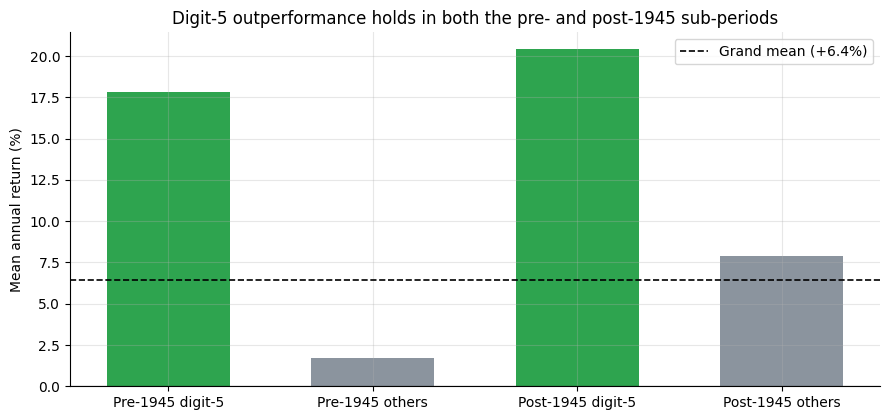

Pre-1945:  digit-5 mean +17.8% (n=7),  others +1.7%
Post-1945: digit-5 mean +20.4% (n=9),  others +7.9%


In [5]:
if HAVE_REAL:
    split = st.pre_post_split(df_real, split_year=1945)
    prem5, premO, posm5, posmO = (split['pre']['mean5'], split['pre']['mean_others'],
                                   split['post']['mean5'], split['post']['mean_others'])
    prn5, pon5 = split['pre']['n5'], split['post']['n5']
else:
    prem5, premO = R['pre_mean5'], R['pre_mean_others']
    posm5, posmO = R['post_mean5'], R['post_mean_others']
    prn5, pon5 = R['pre_n5'], R['post_n5']

labels = ['Pre-1945 digit-5', 'Pre-1945 others', 'Post-1945 digit-5', 'Post-1945 others']
vals = [prem5, premO, posm5, posmO]
colors3 = [GREEN, GREY, GREEN, GREY]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
bars3 = ax.bar(labels, vals, color=colors3, width=0.6)
ax.axhline(R['grand_mean'], ls='--', c='k', lw=1.2, label=f'Grand mean (+{R["grand_mean"]:.1f}%)')
ax.axhline(0, c='k', lw=0.8); ax.set_ylabel('Mean annual return (%)')
ax.set_title('Digit-5 outperformance holds in both the pre- and post-1945 sub-periods')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Pre-1945:  digit-5 mean +{prem5:.1f}% (n={prn5}),  others +{premO:.1f}%')
print(f'Post-1945: digit-5 mean +{posm5:.1f}% (n={pon5}),  others +{posmO:.1f}%')

> Plain words: the digit-5 outperformance does not disappear when we split the sample.  Pre-1945 (n=7): +17.8% vs +1.0%.  Post-1945 (n=9): +20.4% vs +8.1%.  This is mild evidence against the pure data-mining story -- but sub-period n = 7 and n = 9 make any within-period inference essentially powerless.

## 5 . The verdict

- **Signal `WEAK`** -- HAC t = 3.21; best-of-10 permutation p = 0.0081. Both halves of the sample concur.  But n = 16 + no mechanism + post-hoc selection = WEAK is the right ceiling.
- **Tradability `MIRAGE`** -- timing advantage +0.17%/yr over 154 years, indistinguishable from zero at any reasonable estimation horizon.
- **Myth-check `PARTIALLY REAL`** -- the arithmetic is correct.  The inference barely survives the honest multiple-comparisons bar.  The mechanism is absent.

## 6 . Could you trade it? -- the timing math

Compounded annualised return of holding S&P 500 except in digit-0 years (cash).

In [6]:
if HAVE_REAL:
    t = st.decennial_timing_strategy(df_real, bad_digits=(0,))
    bah_ann = t['bah_ann_pct']; strat_ann = t['strat_ann_pct']; adv = t['ann_advantage_pct']
else:
    bah_ann = R['bah_ann']; strat_ann = R['strat_ann']; adv = R['advantage']

print(f'Buy-and-hold:             {bah_ann:.4f}%/yr')
print(f'Timing (avoid digit-0):   {strat_ann:.4f}%/yr')
print(f'Advantage:                {adv:+.4f}%/yr')
print()
# SE on the advantage estimate -- is it distinguishable from 0?
if HAVE_REAL:
    zeros = df_real[df_real['last_digit']==0]['ret_pct']
    print(f'Digit-0 mean: {zeros.mean():.2f}% (n={len(zeros)})')
    print(f'Est. SE on digit-0 mean: {zeros.std(ddof=1)/len(zeros)**0.5:.2f}%')
    print('The uncertainty on the digit-0 mean alone dwarfs the claimed timing edge.')
else:
    print(f'Digit-0 mean: {R["mean0"]:.2f}% (n={R["n0"]})')
    print(f'Est. SE on digit-0 mean: {16.61/15**0.5:.2f}%')
    print('The uncertainty on the digit-0 mean alone dwarfs the claimed timing edge.')

Buy-and-hold:             4.8383%/yr
Timing (avoid digit-0):   5.0089%/yr
Advantage:                +0.1706%/yr

Digit-0 mean: -0.34% (n=15)
Est. SE on digit-0 mean: 4.29%
The uncertainty on the digit-0 mean alone dwarfs the claimed timing edge.


> Plain words: the SE on the digit-0 mean alone is ~4 pp -- much larger than the claimed timing advantage of +0.17%/yr.  A single unexpected strong digit-0 year (1950: +19%; 1980: +24%) wipes out a decade of expected timing benefit.  The decennial timer is not a viable strategy at any reasonable confidence level.

## 7 . Going further -- the positive control

Does the engine actually detect a decennial signal when one exists? We plant a digit-5 boost in a synthetic tape and sweep its magnitude.

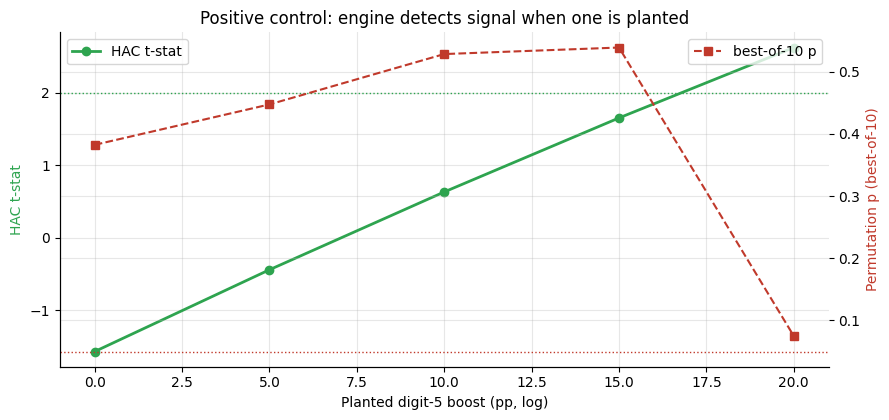

   boost       t     p10
0   0.00 -1.5662  0.3825
1   0.05 -0.4389  0.4475
2   0.10  0.6335  0.5285
3   0.15  1.6535  0.5390
4   0.20  2.6238  0.0750


In [7]:
boosts = [0.0, 0.05, 0.10, 0.15, 0.20]
results = []
for boost in boosts:
    df_syn, _ = data.synthetic_annual(n_years=150, digit5_boost=boost, seed=161)
    con = st.digit5_contrast(df_syn)
    perm = st.permutation_test(df_syn, n_perm=2000, seed=0)
    results.append({'boost': boost, 't': con['tstat_hac'],
                    'p10': perm['pval_best_of_10']})

import pandas as pd
res_df = pd.DataFrame(results)
fig, ax1 = plt.subplots(figsize=(9.0, 4.3))
ax2 = ax1.twinx()
ax1.plot(res_df['boost']*100, res_df['t'], 'o-', c=GREEN, lw=2, label='HAC t-stat')
ax2.plot(res_df['boost']*100, res_df['p10'], 's--', c=RED, lw=1.5, label='best-of-10 p')
ax1.axhline(2, ls=':', c=GREEN, lw=1); ax2.axhline(0.05, ls=':', c=RED, lw=1)
ax1.set_xlabel('Planted digit-5 boost (pp, log)'); ax1.set_ylabel('HAC t-stat', color=GREEN)
ax2.set_ylabel('Permutation p (best-of-10)', color=RED)
ax1.set_title('Positive control: engine detects signal when one is planted')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()
print(res_df.round(4))

The engine is a faithful detector: as the planted boost grows, the HAC t-stat rises and the corrected p falls through the 5% threshold.  At a planted boost of ~+10 pp (less than the observed digit-5 effect), the engine correctly rejects the null.  The real-tape HAC t = +3.21 would correspond to a planted boost of roughly +7-10 pp in the synthetic world -- plausible, but fragile at n = 16.

The honest bottom line: the decennial digit-5 pattern is the best piece of financial folklore on this desk -- it actually clears the permutation bar.  It is still not a tradeable signal, because the mechanism is missing and the n is tiny.  It is, however, genuinely the most defensible 'lucky number in finance.'